# JaxSim as a hardware-accelerated parallel physics engine-advanced usage

JaxSim is developed to optimize synthetic data generation by sampling trajectories using hardware accelerators such as GPUs and TPUs.

In this notebook, you'll learn how to use the key APIs to load a simple robot model (a sphere) and simulate multiple trajectories in parallel on GPUs.

<a target="_blank" href="https://colab.research.google.com/github/ami-iit/jaxsim/blob/main/examples/jaxsim_as_physics_engine_advanced.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

## Prepare the environment

In [1]:
# @title Imports and setup
# import sys

# ================
# Notebook imports
# ================

# import os

# if sys.platform == 'darwin':
#     os.environ["MUJOCO_GL"] = "glfw"
# else:
#     os.environ["MUJOCO_GL"] = "egl"

import jax

import jax.numpy as jnp
import jaxsim.api as js
import rod
from jaxsim import logging
from rod.builder.primitives import BoxBuilder

logging.set_logging_level(logging.LoggingLevel.WARNING)
print(f"Running on {jax.devices()}")

jaxsim[40736] INFO Enabling JAX to use 64-bit precision


Running on [CpuDevice(id=0)]


## Prepare the simulation

JaxSim supports loading robot descriptions from both [SDF][sdformat] and [URDF][urdf] files. This is done using the [`ami-iit/rod`][rod] library, which processes these formats.

The `rod` library also allows creating in-memory models that can be serialized to SDF or URDF. We'll use this functionality to build a sphere model, which will later be used to create the JaxSim model.

[sdformat]: http://sdformat.org/
[urdf]: http://wiki.ros.org/urdf/
[rod]: https://github.com/ami-iit/rod

In [2]:
# @title Create the model description of a box

# Create a SDF model.
# The builder takes care to compute the right inertia tensor for you.
rod_sdf = rod.Sdf(
    version="1.7",
    model=BoxBuilder(x=0.2, y=0.3, z=0.1, mass=1.0, name="box")
    .build_model()
    .add_link()
    .add_inertial()
    .add_visual()
    .add_collision()
    .build(),
)

# Rod allows to update the frames w.r.t. the poses are expressed.
rod_sdf.model.switch_frame_convention(
    frame_convention=rod.FrameConvention.Urdf, explicit_frames=True
)

# Serialize the model to a SDF string.
model_sdf_string = rod_sdf.serialize(pretty=True)
print(model_sdf_string)

<?xml version="1.0" encoding="utf-8"?>
<sdf version="1.7">
  <model name="box">
    <pose>0.0 0.0 0.0 0.0 0.0 0.0</pose>
    <link name="box_link">
      <pose relative_to="__model__">0.0 0.0 0.0 0.0 0.0 0.0</pose>
      <inertial>
        <mass>1.0</mass>
        <inertia>
          <ixx>0.008333333333333333</ixx>
          <iyy>0.0041666666666666675</iyy>
          <izz>0.010833333333333334</izz>
          <ixy>0.0</ixy>
          <ixz>0.0</ixz>
          <iyz>0.0</iyz>
        </inertia>
        <pose relative_to="box_link">0.0 0.0 0.0 0.0 0.0 0.0</pose>
      </inertial>
      <visual name="box_visual">
        <geometry>
          <box>
            <size>0.2 0.3 0.1</size>
          </box>
        </geometry>
        <pose relative_to="box_link">0.0 0.0 0.0 0.0 0.0 0.0</pose>
      </visual>
      <collision name="box_collision">
        <geometry>
          <box>
            <size>0.2 0.3 0.1</size>
          </box>
        </geometry>
        <pose relative_to="box_link">0.0 0.0

In [3]:
import jaxsim

# Create the JaxSim model.
# This is shared among all the parallel instances.
model = js.model.JaxSimModel.build_from_model_description(
    model_description=rod_sdf,
    time_step=0.001,
    contact_model=jaxsim.rbda.contacts.SoftContacts(),
)

# Create the data of a single model.
# We will create a vectorized instance later.
# data = js.data.JaxSimModelData.build(
#     model=model, base_position=jnp.array([0.0, 0.0, 0.11])
# )
data = js.data.random_model_data(
    model=model,
    key=jax.random.PRNGKey(0),
    base_pos_bounds=([0, 0, 0.2], [0, 0, 0.3]),
    base_vel_lin_bounds=(0, 0),
    base_vel_ang_bounds=(0, 0),
)

In [4]:
model.kin_dyn_parameters.contact_parameters

ContactParameters(center=Array([[0.1 , 0.15, 0.05]], dtype=float64), shape_size=Array([[0.2, 0.3, 0.1]], dtype=float64), shape_type=Array([1], dtype=int64))

In [5]:
T = jnp.arange(
    start=0, stop=3.0, step=model.time_step
)  # Initialize the simulated time.

In [6]:
from jaxsim.rbda.contacts import detection, SoftContacts
from jaxsim.api.common import ModelDataWithVelocityRepresentation
from jaxsim import VelRepr

K = 1e5
D = 1e3
mu = μ = 1.0

p = 0.5
q = 0.5


def generate_contact_force(model, data):

    # TODO: This is for a single collision pair.

    m = jnp.array(data.contact_state["tangential_deformation"], dtype=float).squeeze()

    # TODO: The transform of the root link does not match with the actual base position.
    # For this reason, we use the base position instead of the first link transform.
    W_H_L, W_ṗ_C = data.base_transform, data._link_velocities[:, :3][0]

    # Compute the distance and the contact frame transform.
    distance, W_H_C = detection.box_plane_sdf(
        model.terrain,
        model.kin_dyn_parameters.contact_parameters.shape_size.squeeze(),
        W_H_L,
    )

    normal = W_H_C[:, :3, 2]

    CW_fl, ṁ = jax.vmap(
        SoftContacts.hunt_crossley_contact_model,
        in_axes=(None, None, 0, 0, None, None, None, None, None),
    )(W_ṗ_C, m, distance, normal, K, D, mu, p, q)

    # Pack a mixed 6D force.
    CW_f = jnp.zeros((CW_fl.shape[0], 6)).at[:, :3].set(CW_fl)

    # Compute the 6D force transform from the mixed to the inertial-fixed frame.
    W_Xf_CW = jax.vmap(
        lambda C_p_L: jaxsim.math.Adjoint.from_rotation_and_translation(
            translation=C_p_L, inverse=True
        ).T
    )(W_H_C[:, :3, 3] - W_H_L[:3, 3])

    # Compute the 6D force in the inertial-fixed frame.
    W_f_C = jnp.einsum("...ij,...j->...i", W_Xf_CW, CW_f)

    return jnp.sum(W_f_C, axis=0), {"tangential_deformation": jnp.mean(ṁ, axis=0)}

In [7]:
# @title Generate batched initial data

# Create a random JAX key.
key = jax.random.PRNGKey(seed=0)

# Split subkeys for sampling random initial data.
batch_size = 9
row_length = int(jnp.sqrt(batch_size))
row_dist = 0.3 * row_length
key, *subkeys = jax.random.split(key=key, num=batch_size + 1)

# Create the batched data by sampling the height from [0.5, 0.6] meters.
data_batch_t0 = jax.vmap(
    lambda key: js.data.random_model_data(
        model=model,
        key=key,
        base_pos_bounds=([0, 0, 0.1], [0, 0, 0.5]),
        base_vel_lin_bounds=(0, 0),
        base_vel_ang_bounds=(0, 0),
    )
)(jnp.vstack(subkeys))

x, y = jnp.meshgrid(
    jnp.linspace(-row_dist, row_dist, num=row_length),
    jnp.linspace(-row_dist, row_dist, num=row_length),
)
xy_coordinate = jnp.stack([x.flatten(), y.flatten()], axis=-1)

# Reset the x and y position to a grid.
data_batch_t0 = data_batch_t0.replace(
    model=model,
    base_position=data_batch_t0.base_position.at[:, :2].set(xy_coordinate),
)

print("W_p_B(t0)=\n", data_batch_t0.base_position[0:10])

W_p_B(t0)=
 [[-0.9     -0.9      0.41408]
 [ 0.      -0.9      0.33882]
 [ 0.9     -0.9      0.20952]
 [-0.9      0.       0.14332]
 [ 0.       0.       0.39548]
 [ 0.9      0.       0.26203]
 [-0.9      0.9      0.38174]
 [ 0.       0.9      0.29728]
 [ 0.9      0.9      0.41957]]


In [8]:
# @title Create parallel step function

import functools
from typing import Any


# @jax.jit
def step_single(
    model: js.model.JaxSimModel,
    data: js.data.JaxSimModelData,
) -> tuple[js.data.JaxSimModelData, dict[str, Any]]:

    BW_f_C, new_contact_state = generate_contact_force(model=model, data=data)

    W_f_C = ModelDataWithVelocityRepresentation.inertial_to_other_representation(
        array=BW_f_C,
        transform=data.base_transform,
        other_representation=VelRepr.Mixed,
        is_force=True,
    )

    # jax.debug.print("W_f_C=\n{W_f_C}", W_f_C=W_f_C)
    # jax.debug.print("W_p_B=\n{W_p_B}", W_p_B=data.base_position[2])

    # Close step over static arguments.
    return js.model.step(
        model=model,
        data=data,
        link_forces=W_f_C,
        joint_force_references=None,
        contact_state_derivative=new_contact_state,
    )


# @jax.jit
@functools.partial(jax.vmap, in_axes=(None, 0))
def step_parallel(
    model: js.model.JaxSimModel,
    data: js.data.JaxSimModelData,
) -> tuple[js.data.JaxSimModelData, dict[str, Any]]:

    return step_single(
        model=model,
        data=data,
    )


# The first run will be slow since JAX needs to JIT-compile the functions.
_ = step_single(model, data)
_ = step_parallel(model, data_batch_t0)

# Benchmark the execution of a single step.
print("\nSingle simulation step:")
# %timeit step_single(model, data)

# On hardware accelerators, there's a range of batch_size values where
# increasing the number of parallel instances doesn't affect computation time.
# This range depends on the GPU/TPU specifications.
print(f"\nParallel simulation steps (batch_size={batch_size} on {jax.devices()[0]}):")
# %timeit step_parallel(model, data_batch_t0)


Single simulation step:

Parallel simulation steps (batch_size=9 on TFRT_CPU_0):


In [9]:
# @title Run parallel simulation

data_trajectory_list = []
TIME_STOP = 1000

for _ in T[:TIME_STOP]:

    data = step_single(model, data)
    data_trajectory_list.append(data)
    print(f"{int(_*1000)}/{TIME_STOP}", end="\r")

    # with jax.debug_nans(), jax.debug_infs():
    #     data_batch_t0 = step_parallel(model, data_batch_t0)
    #     data_trajectory_list.append(data_batch_t0)

## Visualize trajectory

In [10]:
# Convert a list of PyTrees to a batched PyTree.
# This operation is called 'tree transpose' in JAX.
data_trajectory = jax.tree.map(lambda *leafs: jnp.stack(leafs), *data_trajectory_list)

print(f"W_p_B: shape={data_trajectory.base_position.shape}")

W_p_B: shape=(1000, 3)


C:\Users\fferretti\AppData\Local\Temp\ipykernel_40736\1077805182.py:4: MatplotlibDeprecationWarning: Passing label as a length 9 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(


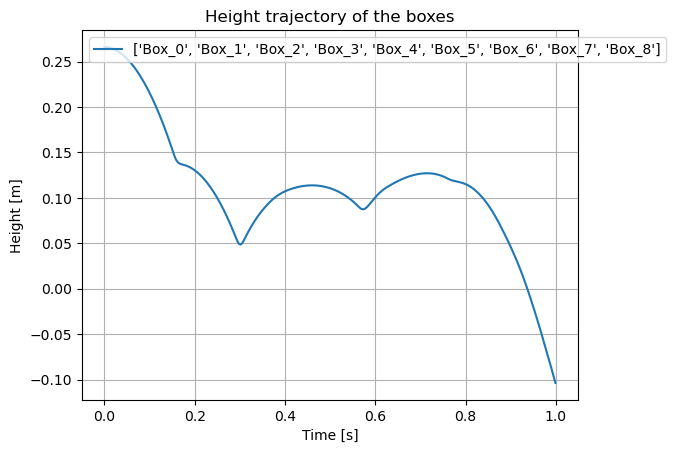

In [11]:
import matplotlib.pyplot as plt


plt.plot(
    T[:TIME_STOP],
    data_trajectory.base_position[:TIME_STOP, 2],
    # data_trajectory.base_position[:TIME_STOP, :, 2],
    label=[f"Box_{k}" for k in range(batch_size)],
)
plt.legend(loc="upper left")
plt.grid(True)
plt.xlabel("Time [s]")
plt.ylabel("Height [m]")
plt.title("Height trajectory of the boxes")
plt.show()

In [12]:
if locals().get("recorder") is not None:
    del recorder

In [13]:
import jaxsim.mujoco

mjcf_string, assets = jaxsim.mujoco.ModelToMjcf.convert(
    model.built_from.model,
    cameras=jaxsim.mujoco.loaders.MujocoCamera.build_from_target_view(
        camera_name="box_cam",
        lookat=[0, 0, 0.3],
        distance=4,
        azimuth=150,
        elevation=-10,
    ),
)

# Create a helper for each parallel instance.
# mj_model_helpers = [
#     jaxsim.mujoco.MujocoModelHelper.build_from_xml(
#         mjcf_description=mjcf_string, assets=assets
#     )
#     for _ in range(batch_size)
# ]
mj_model_helpers = jaxsim.mujoco.MujocoModelHelper.build_from_xml(
    mjcf_description=mjcf_string, assets=assets
)

# Create the video recorder.
recorder = jaxsim.mujoco.MujocoVideoRecorder(
    model=mj_model_helpers.model,
    # model=mj_model_helpers[0].model,
    data=mj_model_helpers.data,
    # data=[helper.data for helper in mj_model_helpers],
    fps=60,
    width=320 * 2,
    height=240 * 2,
)

for data_t in data_trajectory_list[:TIME_STOP][:: int(1 / model.time_step / 60)]:

    mj_model_helpers.set_base_position(position=data_t.base_position)
    mj_model_helpers.set_base_orientation(orientation=data_t.base_quaternion)

    if model.dofs() > 0:
        mj_model_helpers.set_joint_positions(
            positions=data_t.joint_positions, joint_names=model.joint_names()
        )

    # for helper, base_position, base_quaternion, joint_position in zip(
    #     mj_model_helpers,
    #     data_t.base_position,
    #     data_t.base_orientation,
    #     data_t.joint_positions,
    #     strict=True,
    # ):
    #     helper.set_base_position(position=base_position)
    #     helper.set_base_orientation(orientation=base_quaternion)

    #     if model.dofs() > 0:
    #         helper.set_joint_positions(
    #             positions=joint_position, joint_names=model.joint_names()
    #         )

    # Record a new video frame.
    recorder.record_frame(camera_name="box_cam")

In [14]:
import mediapy as media

media.show_video(recorder.frames, fps=recorder.fps)

This browser does not support the video tag.
